In [2]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

Looking in indexes: https://download.pytorch.org/whl/cu126
   ---------------------------------------- 0.0/2.6 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.6 GB 7.2 MB/s eta 0:06:00
   ---------------------------------------- 0.0/2.6 GB 10.5 MB/s eta 0:04:08
   ---------------------------------------- 0.0/2.6 GB 10.2 MB/s eta 0:04:15
   ---------------------------------------- 0.0/2.6 GB 10.1 MB/s eta 0:04:18
   ---------------------------------------- 0.0/2.6 GB 10.0 MB/s eta 0:04:20
   ---------------------------------------- 0.0/2.6 GB 9.9 MB/s eta 0:04:22
   ---------------------------------------- 0.0/2.6 GB 9.9 MB/s eta 0:04:21
   ---------------------------------------- 0.0/2.6 GB 9.9 MB/s eta 0:04:23
   ---------------------------------------- 0.0/2.6 GB 9.8 MB/s eta 0:04:25
   ---------------------------------------- 0.0/2.6 GB 9.8 MB/s eta 0:04:25
   ---------------------------------------- 0.0/2.6 GB 9.9 MB/s eta 0:04:22
   -----------------------------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import torch

In [13]:
torch.manual_seed(42)

## MLP

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

CLEANED_PATH = r"C:\glassIDS\data\processed\cicids2017_cleaned.csv"

df = pd.read_csv(CLEANED_PATH)

feature_cols = []
for c in df.columns:
    if c not in ("Label", "is_attack", "source_file", "Destination Port"):
        feature_cols.append(c)

X = df[feature_cols]
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print(X_train.shape, X_test.shape)
print(list(le.classes_))

(2016638, 77) (504160, 77)
['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack - Brute Force', 'Web Attack - Sql Injection', 'Web Attack - XSS']


In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.mean(axis=0)[:5])
print(X_train_scaled.std(axis=0)[:5])

[-5.41194623e-18  5.63744399e-20  1.69123320e-19  7.58236217e-18
 -3.38246639e-19]
[1. 1. 1. 1. 1.]


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [5]:
from torch.utils.data import Dataset, DataLoader

class FlowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = FlowDataset(X_train_scaled, y_train_enc)
test_dataset = FlowDataset(X_test_scaled, y_test_enc)

BATCH_SIZE = 512

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

X_batch, y_batch = next(iter(train_loader))
print(X_batch.shape, X_batch.dtype)
print(y_batch.shape, y_batch.dtype)

torch.Size([512, 77]) torch.float32
torch.Size([512]) torch.int64


In [6]:
import torch.nn as nn

class SimpleMLP(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.net(x)

model = SimpleMLP(input_size=X_train_scaled.shape[1], num_classes=len(le.classes_)).to(device)
print(model)

SimpleMLP(
  (net): Sequential(
    (0): Linear(in_features=77, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=15, bias=True)
  )
)


In [7]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 5

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    epoch_loss = running_loss / len(train_dataset)
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {epoch_loss:.4f}")

Epoch 1/5, Loss: 0.0919
Epoch 2/5, Loss: 0.0468
Epoch 3/5, Loss: 0.0414
Epoch 4/5, Loss: 0.0367
Epoch 5/5, Loss: 0.0318


In [9]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

accuracy = correct / total
print(f"Test accuracy (quick sanity check only): {accuracy:.4f}")

Test accuracy (quick sanity check only): 0.9921


In [8]:
from sklearn.utils.class_weight import compute_class_weight

# split the ORIGINAL (unscaled) training data into train_sub / val
X_train_sub, X_val, y_train_sub_enc, y_val_enc = train_test_split(
    X_train, y_train_enc, test_size=0.15, stratify=y_train_enc, random_state=42
)

# refit the scaler on train_sub ONLY, not the full X_train
scaler = StandardScaler()
X_train_sub_scaled = scaler.fit_transform(X_train_sub)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)  # re-transform test with this new scaler too, for consistency

# per-class weights for CrossEntropyLoss — the multiclass "balanced" equivalent
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_sub_enc),
    y=y_train_sub_enc,
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print(X_train_sub.shape, X_val.shape, X_test.shape)
print(class_weights_tensor)

(1714142, 77) (302496, 77) (504160, 77)
tensor([8.0214e-02, 8.6311e+01, 1.3128e+00, 1.6337e+01, 9.7227e-01, 3.2145e+01,
        3.1206e+01, 2.8335e+01, 1.4285e+04, 4.5710e+03, 1.8530e+00, 5.2205e+01,
        1.1439e+02, 8.1626e+03, 2.5738e+02], device='cuda:0')


In [10]:
train_sub_dataset = FlowDataset(X_train_sub_scaled, y_train_sub_enc)
val_dataset = FlowDataset(X_val_scaled, y_val_enc)
test_dataset = FlowDataset(X_test_scaled, y_test_enc)

train_sub_loader = DataLoader(train_sub_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [11]:
import copy
import torch.nn.functional as F

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.001)

MAX_EPOCHS = 50
PATIENCE = 5
GRAD_CLIP_MAX_NORM = 1.0

best_val_loss = float("inf")
epochs_no_improve = 0
best_model_state = None
train_losses, val_losses = [], []

for epoch in range(MAX_EPOCHS):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_sub_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_MAX_NORM)
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    train_loss = running_loss / len(train_sub_dataset)
    train_losses.append(train_loss)

    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_val_loss += loss.item() * X_batch.size(0)

    val_loss = running_val_loss / len(val_dataset)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

model.load_state_dict(best_model_state)

Epoch 1: train_loss=0.2776, val_loss=0.2560
Epoch 2: train_loss=0.2336, val_loss=0.2782
Epoch 3: train_loss=0.2191, val_loss=0.2351
Epoch 4: train_loss=0.2034, val_loss=0.2316
Epoch 5: train_loss=0.2016, val_loss=0.2504
Epoch 6: train_loss=0.1974, val_loss=0.2178
Epoch 7: train_loss=0.1912, val_loss=0.2501
Epoch 8: train_loss=0.1821, val_loss=0.2594
Epoch 9: train_loss=0.1772, val_loss=0.2415
Epoch 10: train_loss=0.1858, val_loss=0.2339
Epoch 11: train_loss=0.1828, val_loss=0.2943
Early stopping triggered at epoch 11


<All keys matched successfully>

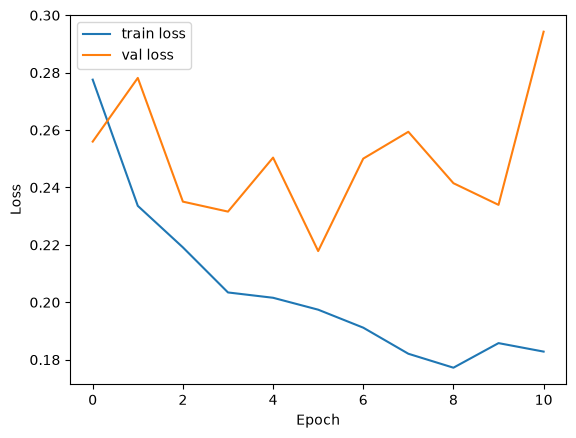

In [12]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="train loss")
plt.plot(val_losses, label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 1-D CNN Model

In [14]:
class SimpleCNN(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.relu = nn.ReLU()

        pooled_length = input_size // 2
        self.fc1 = nn.Linear(32 * pooled_length, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = x.unsqueeze(1)          # (batch, 77) -> (batch, 1, 77): add the channel dimension Conv1d expects
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = x.flatten(start_dim=1)  # collapse (batch, channels, length) down to (batch, features) for the Linear layers
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [15]:
def train_model(model, train_loader, val_loader, criterion, optimizer,
                 max_epochs=50, patience=5, grad_clip_max_norm=1.0):
    best_val_loss = float("inf")
    epochs_no_improve = 0
    best_model_state = None
    train_losses, val_losses = [], []

    for epoch in range(max_epochs):
        model.train()
        running_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip_max_norm)
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(train_loss)

        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                running_val_loss += loss.item() * X_batch.size(0)

        val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break

    model.load_state_dict(best_model_state)
    return model, train_losses, val_losses

In [16]:
cnn_model = SimpleCNN(input_size=X_train_sub.shape[1], num_classes=len(le.classes_)).to(device)
cnn_criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

cnn_model, cnn_train_losses, cnn_val_losses = train_model(
    cnn_model, train_sub_loader, val_loader, cnn_criterion, cnn_optimizer
)

Epoch 1: train_loss=0.6811, val_loss=0.3355
Epoch 2: train_loss=0.3180, val_loss=0.2770
Epoch 3: train_loss=0.2480, val_loss=0.2543
Epoch 4: train_loss=0.2645, val_loss=0.2828
Epoch 5: train_loss=0.2261, val_loss=0.2836
Epoch 6: train_loss=0.2198, val_loss=0.2660
Epoch 7: train_loss=0.2117, val_loss=0.3192
Epoch 8: train_loss=0.2048, val_loss=0.2528
Epoch 9: train_loss=0.1905, val_loss=0.2260
Epoch 10: train_loss=0.1965, val_loss=0.2631
Epoch 11: train_loss=0.2275, val_loss=0.2944
Epoch 12: train_loss=0.1743, val_loss=0.3049
Epoch 13: train_loss=0.1759, val_loss=0.2898
Epoch 14: train_loss=0.1660, val_loss=0.2662
Early stopping triggered at epoch 14


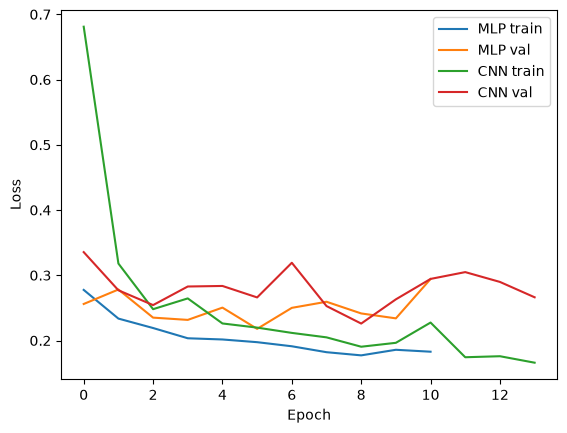

In [17]:
plt.plot(train_losses, label="MLP train")
plt.plot(val_losses, label="MLP val")
plt.plot(cnn_train_losses, label="CNN train")
plt.plot(cnn_val_losses, label="CNN val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [18]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import torch.nn.functional as F
import numpy as np

def evaluate_model(model, loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.append(preds.cpu().numpy())
            all_labels.append(y_batch.numpy())
            all_probs.append(probs.cpu().numpy())

    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_labels)
    y_proba = np.concatenate(all_probs)

    print(classification_report(y_true, y_pred, target_names=le.classes_, digits=3))
    macro_auc = roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro")
    print(f"Macro ROC-AUC (OvR): {macro_auc:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    return pd.DataFrame(cm, index=le.classes_, columns=le.classes_)

print("=== MLP ===")
mlp_cm = evaluate_model(model, test_loader)
print(mlp_cm)

=== MLP ===
                            precision    recall  f1-score   support

                    BENIGN      0.998     0.919     0.957    419012
                       Bot      0.033     0.997     0.063       390
                      DDoS      0.993     0.992     0.992     25603
             DoS GoldenEye      0.624     0.998     0.768      2057
                  DoS Hulk      0.962     0.987     0.974     34569
          DoS Slowhttptest      0.632     0.996     0.773      1046
             DoS slowloris      0.774     0.959     0.857      1077
               FTP-Patator      0.448     0.997     0.618      1186
                Heartbleed      0.667     1.000     0.800         2
              Infiltration      0.065     0.857     0.121         7
                  PortScan      0.940     0.998     0.968     18139
               SSH-Patator      0.043     0.977     0.083       644
  Web Attack - Brute Force      0.108     0.905     0.193       294
Web Attack - Sql Injection      0.0

In [19]:
print("=== CNN ===")
cnn_cm = evaluate_model(cnn_model, test_loader)
print(cnn_cm)

=== CNN ===
                            precision    recall  f1-score   support

                    BENIGN      0.999     0.932     0.964    419012
                       Bot      0.036     0.995     0.070       390
                      DDoS      0.912     0.999     0.954     25603
             DoS GoldenEye      0.912     0.997     0.952      2057
                  DoS Hulk      0.854     0.996     0.920     34569
          DoS Slowhttptest      0.813     0.995     0.895      1046
             DoS slowloris      0.861     0.988     0.920      1077
               FTP-Patator      0.875     0.991     0.929      1186
                Heartbleed      1.000     0.500     0.667         2
              Infiltration      0.070     1.000     0.131         7
                  PortScan      0.739     0.999     0.850     18139
               SSH-Patator      0.342     0.932     0.501       644
  Web Attack - Brute Force      0.137     0.901     0.238       294
Web Attack - Sql Injection      0.0